In [2]:
from Bio.PDB import PDBList, PDBParser
import os
# скачиваем структуру грамицидина А
pdbl=PDBList()
pdb_id='1MAG'

# сохраняем в data/structures/
os.makedirs('../data/structures', exist_ok=True)
pdbl.retrieve_pdb_file(pdb_id, file_format='pdb',pdir='../data/structures/')

'../data/structures/pdb1mag.ent'

In [5]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure('gramicidin_A', "../data/structures/pdb1mag.ent")

print(f'Обьект структуры:{structure}')
print(f"Количество моделей: {len(structure)}")

# Разбираем структуру первой модели
model = structure[0]
for chain in model:
    print(f"Цепь: {chain.id}")
    residues = list(chain.get_residues())
    print(f"  Количество остатков: {len(residues)}")
    print(f"  Первый остаток: {residues[0].resname}")
    print(f"  Последний остаток: {residues[-1].resname}")

Обьект структуры:<Structure id=gramicidin_A>
Количество моделей: 1
Цепь: A
  Количество остатков: 16
  Первый остаток: FVA
  Последний остаток: ETA
Цепь: B
  Количество остатков: 16
  Первый остаток: FVA
  Последний остаток: ETA


In [6]:
# найдем длину канала 
import numpy as np

# найдем координаты всех CA - атомов
ca_atoms = []
for chain in model:
    for residue in chain:
        # проверяем наличие CA атома
        if 'CA' in residue:
            ca_atoms.append(residue['CA'].get_vector().get_array())
ca_coords = np.array(ca_atoms)

# найдем длину по z
z_coords = ca_coords[:,2]
z_min = z_coords.min()
z_max = z_coords.max()
channel_length = z_max - z_min
print(f"Найдено CA-атомов: {len(ca_atoms)}")
print(f"Нижняя граница (Z_min): {z_min:.2f} Å")
print(f"Верхняя граница (Z_max): {z_max:.2f} Å")
print(f"Длина скелета канала: {channel_length:.2f} Å")
print(f"Толщина гидрофобной части липидной мембраны обычно ~26-30 Å.")

Найдено CA-атомов: 32
Нижняя граница (Z_min): -15.67 Å
Верхняя граница (Z_max): 8.83 Å
Длина скелета канала: 24.51 Å
Толщина гидрофобной части липидной мембраны обычно ~26-30 Å.


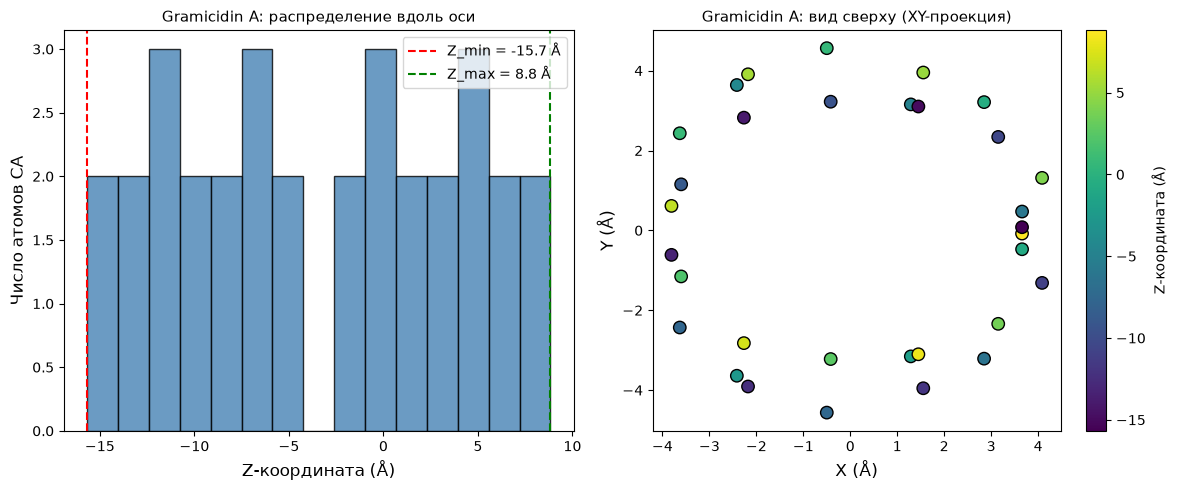

График успешно сохранен в папку results/


In [8]:
# построим визуализацию распределения атомов вдоль оси z и вид сверху на пору
import matplotlib.pyplot as plt
import os
os.makedirs("../results", exist_ok=True)
# Настраиваем размер фигуры (2 графика рядом)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# --- График 1: Гистограмма распределения по Z ---
ax1.hist(z_coords, bins=15, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Z-координата (Å)', fontsize=12)
ax1.set_ylabel('Число атомов CA', fontsize=12)
ax1.set_title('Gramicidin A: распределение вдоль оси', fontsize=11)
ax1.axvline(z_min, color='red', linestyle='--', label=f'Z_min = {z_min:.1f} Å')
ax1.axvline(z_max, color='green', linestyle='--', label=f'Z_max = {z_max:.1f} Å')
ax1.legend()
# --- График 2: XY-проекция ---
xy_coords = ca_coords[:, :2]
# Рисуем точки, цвет зависит от глубины (Z)
scatter = ax2.scatter(xy_coords[:, 0], xy_coords[:, 1], 
                      c=z_coords, cmap='viridis', s=80, edgecolor='black')
ax2.set_xlabel('X (Å)', fontsize=12)
ax2.set_ylabel('Y (Å)', fontsize=12)
ax2.set_title('Gramicidin A: вид сверху (XY-проекция)', fontsize=11)
# Добавляем цветовую карту
plt.colorbar(scatter, ax=ax2, label='Z-координата (Å)')

# Сохраняем и показываем
plt.tight_layout()
plt.savefig('../results/gramicidin_A_structure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("График успешно сохранен в папку results/")